TABELA DE RESULTADOS DO EXPERIMENTO:
 Registros (N)  Tempo Linear (ms)  Tempo Indexado (ms)  Ganho (%)
          1000             0.0718               0.0024      96.68
         10000             0.5565               0.0052      99.06
        100000             7.4079               0.0043      99.94
        500000            35.2077               0.0055      99.98
       1000000           277.8482               0.0052     100.00

[SUCESSO] Gráfico 'grafico.png' gerado e salvo.


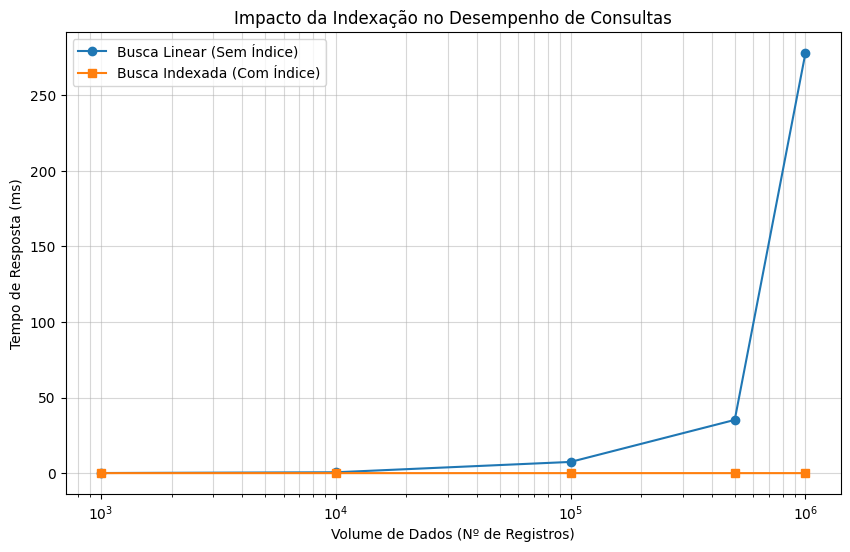

In [1]:
import pandas as pd
import time
import matplotlib.pyplot as plt
import random

def gerar_dados(n):
    """Simula uma tabela de banco de dados com N registros."""
    return [{'id': i, 'dado': f'valor_{i}'} for i in range(n)]

def busca_linear(dataset, alvo):
    """Simula um Full Table Scan."""
    for item in dataset:
        if item['id'] == alvo:
            return item
    return None

def busca_indexada(index, alvo):
    """Simula uma consulta via Índice (Hash)."""
    return index.get(alvo)

def executar_experimento():
    escalas = [1000, 10000, 100000, 500000, 1000000]
    resultados = []

    for n in escalas:
        # Preparação
        dados = gerar_dados(n)
        indice = {item['id']: item for item in dados}
        alvo = n - 1  # Busca o último elemento para pior caso na linear

        # Teste Linear
        start = time.time()
        busca_linear(dados, alvo)
        tempo_linear = (time.time() - start) * 1000 # convertendo para ms

        # Teste Indexado
        start = time.time()
        busca_indexada(indice, alvo)
        tempo_indexado = (time.time() - start) * 1000

        resultados.append({
            'Registros (N)': n,
            'Tempo Linear (ms)': round(tempo_linear, 4),
            'Tempo Indexado (ms)': round(tempo_indexado, 4),
            'Ganho (%)': round(((tempo_linear - tempo_indexado) / (tempo_linear + 1e-9)) * 100, 2)
        })

    # Gerar DataFrame
    df = pd.DataFrame(resultados)
    print("TABELA DE RESULTADOS DO EXPERIMENTO:")
    print(df.to_string(index=False))

    # Gerar Gráfico
    plt.figure(figsize=(10, 6))
    plt.plot(df['Registros (N)'], df['Tempo Linear (ms)'], marker='o', label='Busca Linear (Sem Índice)')
    plt.plot(df['Registros (N)'], df['Tempo Indexado (ms)'], marker='s', label='Busca Indexada (Com Índice)')

    plt.title('Impacto da Indexação no Desempenho de Consultas')
    plt.xlabel('Volume de Dados (Nº de Registros)')
    plt.ylabel('Tempo de Resposta (ms)')
    plt.xscale('log') # Escala logarítmica para melhor visualização
    plt.grid(True, which="both", ls="-", alpha=0.5)
    plt.legend()

    # Salvar Gráfico
    plt.savefig('grafico.png')
    print("\n[SUCESSO] Gráfico 'grafico.png' gerado e salvo.")
    plt.show()

if __name__ == "__main__":
    executar_experimento()